In [1]:
import pandas as pd

df = pd.read_csv("datasets/online_retail.csv", encoding="ISO-8859-1")
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df.columns


Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [4]:
df = df.rename(columns={
    'Invoice':'InvoiceNo',
    'Price':'UnitPrice',
    'Customer ID':'CustomerID'
})

df.columns


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [5]:
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']


In [6]:
current_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (current_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']
rfm.head()


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,12,77556.46
12347.0,1,8,5633.32
12348.0,74,5,2019.40
12349.0,18,4,4428.69
12350.0,309,1,334.40


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)


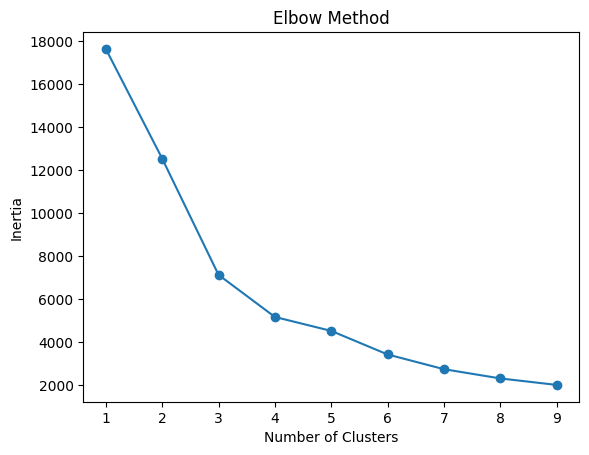

<Figure size 640x480 with 0 Axes>

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

plt.savefig("visualizations/elbow_method.png", dpi=300, bbox_inches="tight")


In [9]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,325,12,77556.46,1
12347.0,1,8,5633.32,1
12348.0,74,5,2019.40,1
12349.0,18,4,4428.69,1
12350.0,309,1,334.40,0


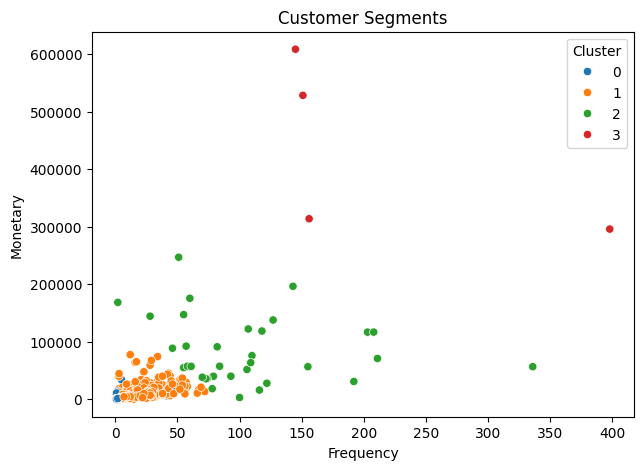

<Figure size 640x480 with 0 Axes>

In [10]:
import seaborn as sns

plt.figure(figsize=(7,5))
sns.scatterplot(x=rfm['Frequency'], y=rfm['Monetary'], hue=rfm['Cluster'], palette='tab10')
plt.title("Customer Segments")
plt.show()

plt.savefig("visualizations/customer_clusters.png", dpi=300, bbox_inches="tight")


In [11]:
rfm.groupby('Cluster').mean()


,Recency,Frequency,Monetary
Cluster,,,
0,462.032032,2.212212,765.244446
1,66.005728,7.307732,3009.402451
2,24.942857,103.714286,83086.079771
3,2.500000,212.500000,436835.792500


Key Findings:
- Small number of customers generate most revenue
- Many customers purchase only once
- Loyal customers identified
- Marketing campaigns can be targeted

Recommendation:
Offer loyalty rewards to high value customers
Send offers to inactive customers
Avoid blanket discounts
